# 02 Introduction to Signal Highlighting


This notebook should introduce a method in the context of xAI. Signal highlighting should show you the importance of a signal and which part of the signal is important for the downstream task.

## Import Data

At first we do all the relevant imports of the modules for the data import and the preperation for the network develpoment

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

Define the function to import csv files

In [2]:
downsampling_factor = 1
start_at_value = 1

def read_csv(data_file_path,num_of_cols_to_be_read):
    read_file = np.loadtxt(data_file_path, delimiter=";")


    if num_of_cols_to_be_read==12:
      AccXS=read_file[start_at_value::downsampling_factor,0]
      AccYS=read_file[start_at_value::downsampling_factor,1]
      AccZS=read_file[start_at_value::downsampling_factor,2]
      AccXW=read_file[start_at_value::downsampling_factor,3]
      AccYW=read_file[start_at_value::downsampling_factor,4]
      AccZW=read_file[start_at_value::downsampling_factor,5]
      GyrX=read_file[start_at_value::downsampling_factor,6]
      GyrY=read_file[start_at_value::downsampling_factor,7]
      GyrZ=read_file[start_at_value::downsampling_factor,8]
      MagX=read_file[start_at_value::downsampling_factor,9]
      MagY=read_file[start_at_value::downsampling_factor,10]
      MagZ=read_file[start_at_value::downsampling_factor,11]

      return AccXS,AccYS,AccZS,AccXW,AccYW,AccZW,GyrX,GyrY,GyrZ,MagX,MagY,MagZ

    elif num_of_cols_to_be_read==6:
      AccX=read_file[1:,0]
      AccY=read_file[1:,1]
      AccZ=read_file[1:,2]
      GyrX=read_file[1:,3]
      GyrY=read_file[1:,4]
      GyrZ=read_file[1:,5]

      return AccX,AccY,AccZ,GyrX,GyrY,GyrZ

    else:
      AccX=read_file[1:,0]
      AccY=read_file[1:,1]
      AccZ=read_file[1:,2]

      return AccX,AccY,AccZ



Define the folder where the data lies to be processed and check how many samples are available

In [4]:
path="../Data/Golfball_Impact/12_DOF"

In [5]:
entries = os.listdir(path)

print(len(entries))

282


Now we need to import all files and form a dataset from it. There will be a dataset for training, validation and testing

In [6]:
number_of_steps=int((401-start_at_value)/downsampling_factor)
num_of_input_signals = 12

# allocate the X_data np array
X_data=np.empty([len(entries),number_of_steps,num_of_input_signals])
Y_data=np.empty([len(entries),1,3])
marker=np.empty(len(entries))

counter=0
for file in entries:
    #print(path+file)
    inputdata=read_csv(path+'/'+file,num_of_input_signals)
    if file[0][0] == '0': #inner = 0, outer = 2, central = 1 ????
      outputdata=np.array([1,0,0])
      X_data[counter,:,:]=np.transpose(inputdata)
      Y_data[counter,:,:]=np.transpose(outputdata)
      marker[counter]=0
      counter=counter+1
    elif file[0][0] == '1': #inner = 0, outer = 2, central = 1 ????
      outputdata=np.array([0,1,0])
      X_data[counter,:,:]=np.transpose(inputdata)
      Y_data[counter,:,:]=np.transpose(outputdata)
      marker[counter]=1
      counter=counter+1
    elif file[0][0] == '2': #inner = 0, outer = 2, central = 1 ????
      outputdata=np.array([0,0,1])
      X_data[counter,:,:]=np.transpose(inputdata)
      Y_data[counter,:,:]=np.transpose(outputdata)
      marker[counter]=2
      counter=counter+1
    else:
      print('cannot read the hit location from csv file name on {} and file {}'.format(counter,file))


X_data=X_data[range(0,counter),:,:]
Y_data=Y_data[range(0,counter),:,:]
Y_data=np.reshape(Y_data,[Y_data.shape[0],Y_data.shape[2]])

indices4inner=np.where(marker==0)
indices4central=np.where(marker==1)
indices4outer=np.where(marker==2)


How does the data look like?

In [7]:
print(X_data.shape)
print(Y_data.shape)

print(X_data[0,0,:])
print(Y_data[0,:])

(282, 400, 12)
(282, 3)
[0.5045459  0.49857788 0.50000661 0.50177382 0.50289954 0.49416325
 0.48948214 0.51007143 0.53892857 0.50002352 0.49998359 0.50001255]
[1. 0. 0.]


As can be seen, the inputs (X_data) show values between 0 and 1 and refer to AccXS, AccYS, AccZS, AccXW, AccYW, AccZW, GyrX, GyrY, GyrZ, MagX, MagY, MagZ with S in Acc meaning stationary coordinate system and W meaning world coordinate system. Y_data is one hot encoded with inner, central, outer.

Now let's load the model

In [8]:
# ------------------------------------------------------------------------------
# standard modules
import sys
import time
import statistics
import logging

from itertools import groupby
from IPython.display import display

# Visualization
import PIL

# metrics and splitting
from sklearn import metrics
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import StratifiedKFold

# keras/tensorflow modules
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Activation
from tensorflow.keras.layers import GlobalAveragePooling1D, Dense
from tensorflow.keras.layers import ReLU, add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
# for dedugging
from IPython.core.debugger import set_trace

# statistics
from collections import Counter

device_name = tf.test.gpu_device_name()
print(device_name)

In [11]:
network_name = "Optimal_Network"
save_path = "../Network_Development/Models/" + network_name + ".keras"
model=load_model(save_path)

Let's see the model and how it is built



In [12]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 400, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 400, 64)   │      6,208 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 64)   │        256 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 400, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 400, 64)   │     20,544 │ activation_9[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 64)   │        256 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 400, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 400, 64)   │        832 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 400, 64)   │     12,352 │ activation_10[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 64)   │        256 │ conv1d_14[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 64)   │        256 │ conv1d_13[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 400, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 400, 64)   │          0 │ add_3[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 400, 128)  │     65,664 │ activation_11[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 128)  │        512 │ conv1d_15[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 400, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 400, 128)  │     82,048 │ activation_12[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 128)  │        512 │ conv1d_16[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 400, 128)  │          0 │ batch_normalizat

 Total params: 1,534,731 (5.85 MB)

 Trainable params: 510,723 (1.95 MB)

 Non-trainable params: 2,560 (10.00 KB)

 Optimizer params: 1,021,448 (3.90 MB)

activation_17 and dense_1 seem to be the relevant layers to have a close look at.

In [13]:
conv_output = model.get_layer("activation_17").output
pred_output = model.get_layer("dense_1").output
model = Model(model.input, outputs=[conv_output, pred_output])
conv,pred = model.predict(X_data)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


And show the performance of the loaded network

In [14]:
def plot_confusion_matrix(cm, names, title='Confusion matrix',
                            cmap=plt.cm.Blues, normalize=False):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(names))
    plt.xticks(tick_marks, names, rotation=45)
    plt.yticks(tick_marks, names)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    # Add text annotations
    thresh = cm.max() / 2.
    for i, j in ((i, j) for i in range(cm.shape[0]) for j in range(cm.shape[1])):
        plt.text(j, i, f"{cm[i, j]:.2f}",
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

Accuracy: 0.9905437352245863
Normalized confusion matrix


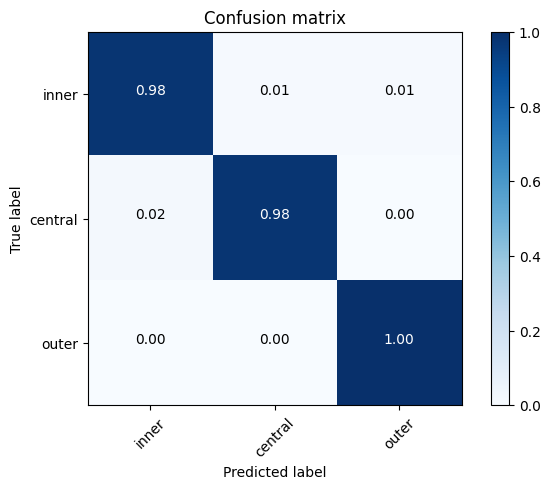

In [15]:
pred_one_hot = np.zeros_like(pred)
pred_one_hot[np.arange(len(pred)), pred.argmax(1)] = 1
accuracy = np.mean(pred_one_hot == Y_data)
print(f"Accuracy: {accuracy}")
cm = metrics.confusion_matrix(Y_data.argmax(1), pred_one_hot.argmax(1))
classes = ['inner', 'central', 'outer']
plot_confusion_matrix(cm, classes, normalize=True) # Added normalize=True

## Signal Highlighting

Now let's have a look on how the network comes to an conclusion.

In [16]:
conv,pred = model.predict(X_data)
print(conv.shape)
summed_conv = np.sum(conv, axis=2, keepdims=True)
print(summed_conv.shape)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
(282, 400, 128)
(282, 400, 1)


946.14026
1.0


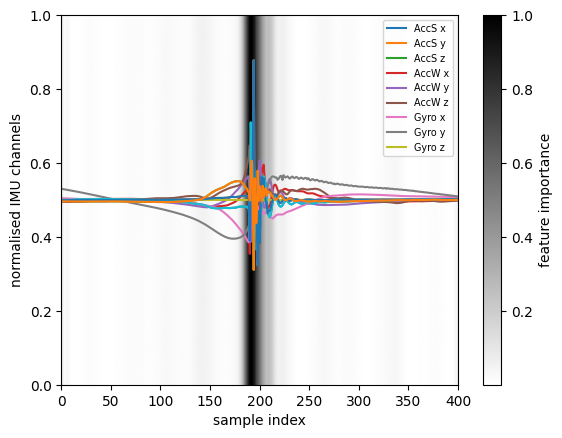

In [17]:
from matplotlib.colors import Normalize

index = 150

print(summed_conv[index,:,0].max())

maximum = summed_conv[index,:,0].max()

norm = Normalize(vmin=0, vmax=maximum)
normed_data = norm(summed_conv[index,:,0])
print(normed_data.max())
plt.figure()
plt.plot(X_data[index,:,1],label="AccS x")
plt.plot(X_data[index,:,2],label="AccS y")
plt.plot(X_data[index,:,3],label="AccS z")

plt.plot(X_data[index,:,4],label="AccW x")
plt.plot(X_data[index,:,5],label="AccW y")
plt.plot(X_data[index,:,6],label="AccW z")

plt.plot(X_data[index,:,7],label="Gyro x")
plt.plot(X_data[index,:,8],label="Gyro y")
plt.plot(X_data[index,:,9],label="Gyro z")

plt.plot(X_data[index,:,1],label="Mag x")
plt.plot(X_data[index,:,2],label="Mag y")
plt.plot(X_data[index,:,3],label="Mag z")

#plt.plot(summed_conv[0, :,0])
#plt.imshow(summed_conv[index,:,:].reshape(1,-1), cmap='gist_yarg', aspect='auto', extent=[0, 400, 0, 1])
plt.imshow(normed_data.reshape(1,-1), cmap='gist_yarg', aspect='auto', extent=[0, 400, 0, 1])
#plt.legend(["Acc","Gyro","Mag"],loc='upper right')
cbar = plt.colorbar()
cbar.set_label('feature importance')
plt.ylabel("normalised IMU channels")
plt.xlabel("sample index")
#plt.set(xlabel='', ylabel='Normalized IMU Data')

handles, labels = plt.gca().get_legend_handles_labels()

# Create a list of indices to show in the legend
show_indices = [0,1, 2,3,4,5,6,7,8]

# Create a filtered list of handles and labels based on the show_indices
filtered_handles = [handles[i] for i in show_indices]
filtered_labels = [labels[i] for i in show_indices]

# Add a legend with filtered handles and labels
plt.legend(filtered_handles, filtered_labels, fontsize='x-small',loc='upper right')
plt.savefig('Heatmap.png', dpi=300, bbox_inches='tight')